In [1]:
import isofit
from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_simple, invert_analytical
from isofit.configs import configs
from isofit.core.geometry import Geometry
from isofit.utils.apply_oe import apply_oe 

from collections import OrderedDict

import os
from spectral.io import envi
import numpy as np
import ray
import logging
import json
from glob import glob
import matplotlib.pyplot as plt

import sys
sys.path.append('/store/carroll/repos/neon-isofit/')
from utilities import viz_rfl_subset

from isoplots import plots
import xarray as xr

%matplotlib widget

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

In [2]:
data = '/store/carroll/col/data/2018/'
home = os.path.join(data, 'test_flightlines/')
raw_dir = os.path.join(home, 'subsets/')

out_figs = '/store/carroll/col/figs/'

version = 'modtran_20250922'
flight_id = 'NIS01_20180612_155442'

working_dir = os.path.join(home, f'{flight_id}_{version}')
fp_rcc = os.path.join('/store/carroll/col/data/2018/test_rccs/rcc_frankenstein_20250908.txt')

fp = glob(os.path.join(working_dir, 'output', '*_rfl.hdr'))[0]
wl = np.array([float(x) for x in envi.read_envi_header(fp)['wavelength']])
def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))
wl_nan = wl.copy()
wl_nan[closest_wl(1360):closest_wl(1410)] = np.nan
wl_nan[closest_wl(1800):closest_wl(1970)] = np.nan

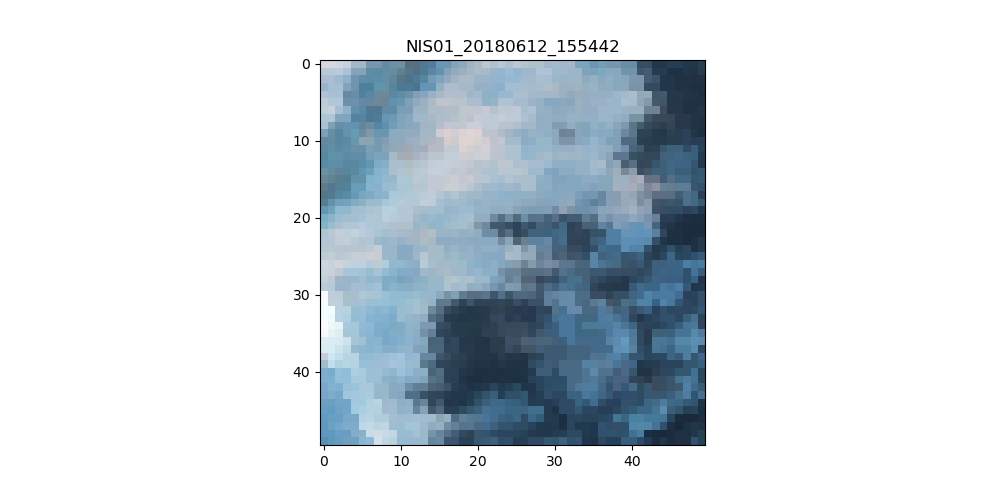

In [3]:
# rdn rgb

fig = plt.figure(figsize=(10,5))

# fp = glob(os.path.join(working_dir, 'output', f'{flight_id}_rfl.hdr'))[0]
fp = glob(os.path.join(raw_dir, f'{flight_id}_rdn.hdr'))[0]
rgb = envi.open(fp).open_memmap()[:,:,np.array([60,40,30])].copy()
plt.imshow(rgb / np.nanmax(rgb, axis=(0, 1)))
plt.title(flight_id)

plt.show()

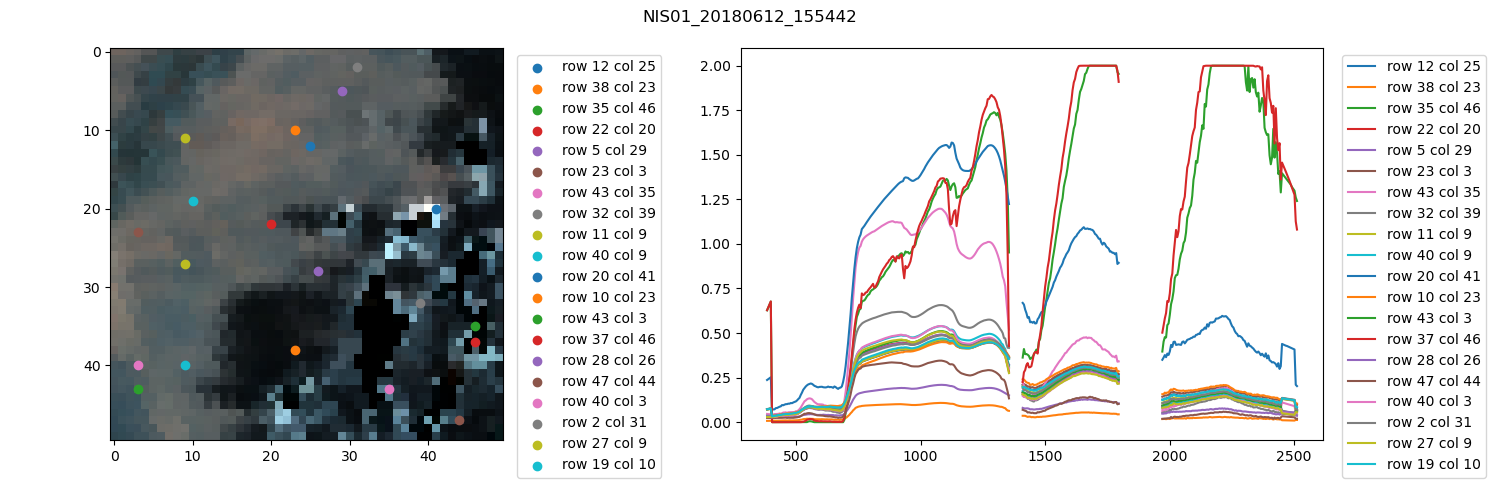

In [29]:
# plot some spectra - modtran run 

size = 50
row1 = 0; col1 = 0

working_dir = os.path.join(home, 'NIS01_20180612_155442_modtran_20250922')
viz_rfl_subset(flight=flight_id, working_dir=working_dir, row1=row1, col1=col1, size=size, n_sample=20, wl=wl_nan)

# plt.savefig(os.path.join(out_figs, f'rfl_{flight}_{version}_row{row1}_col{col1}.png'), dpi=300)

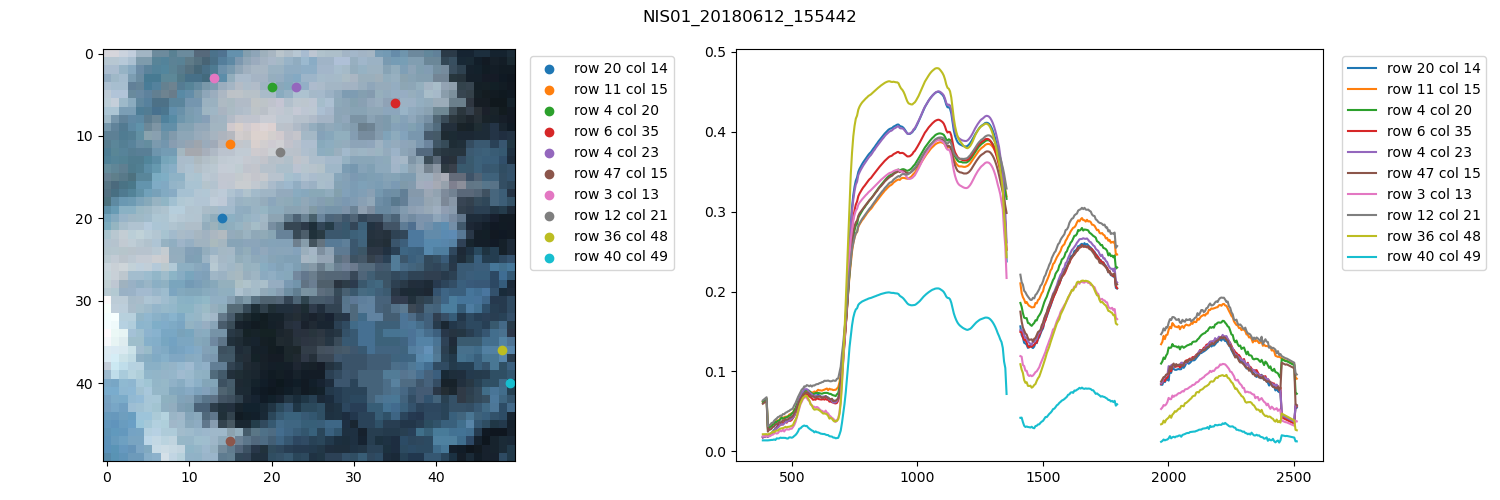

In [6]:
# what did the 1c outputs look like?

# plot some spectra

size = 50
# row1 = 2000; col1 = 600
row1 = 0; col1 = 0

working_dir_1c = os.path.join(home, 'NIS01_20180612_155442_20251001_1c')
viz_rfl_subset(flight=flight_id, working_dir=working_dir_1c, row1=row1, col1=col1, size=size, n_sample=10, wl=wl_nan)

# plt.savefig(os.path.join(out_figs, f'rfl_{flight}_{version}_row{row1}_col{col1}.png'), dpi=300)

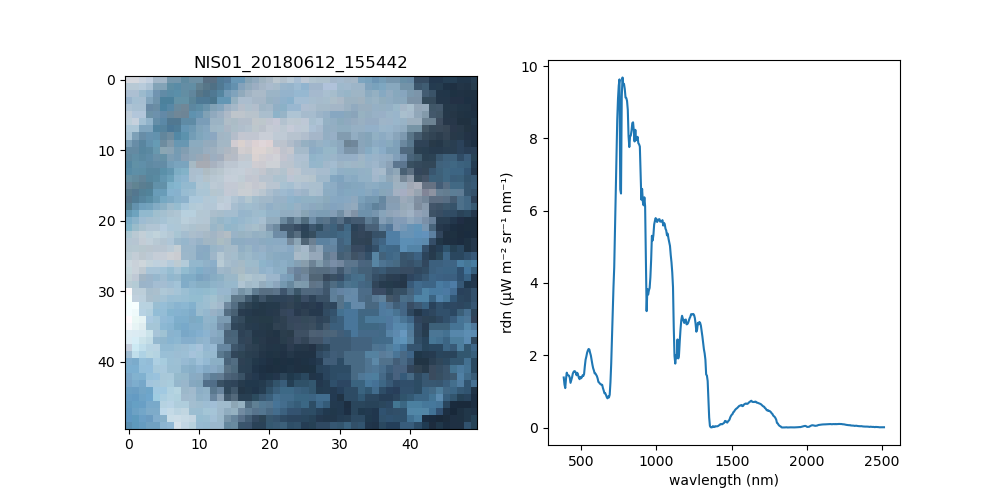

In [27]:

fig, axs = plt.subplots(ncols=2, figsize=(10,5))

rgb = envi.open(fp).open_memmap()[:,:,np.array([60,40,30])].copy()
axs[0].imshow(rgb / np.nanmax(rgb, axis=(0, 1)))
axs[0].set_title(flight_id)

axs[1].plot(wl, px)
axs[1].set_xlabel('wavlength (nm)')
axs[1].set_ylabel('rdn (µW cm⁻² sr⁻¹ nm⁻¹)')

plt.show()

In [19]:
# just to confirm that I have the right px
working_dir_6c = os.path.join(home, 'NIS01_20180612_155442_6c_20250923')
fp = glob(os.path.join(working_dir_6c, 'output', f'{flight_id}_rfl.hdr'))[0]
rfl = envi.open(fp).open_memmap()
px = rfl[44,33,:]


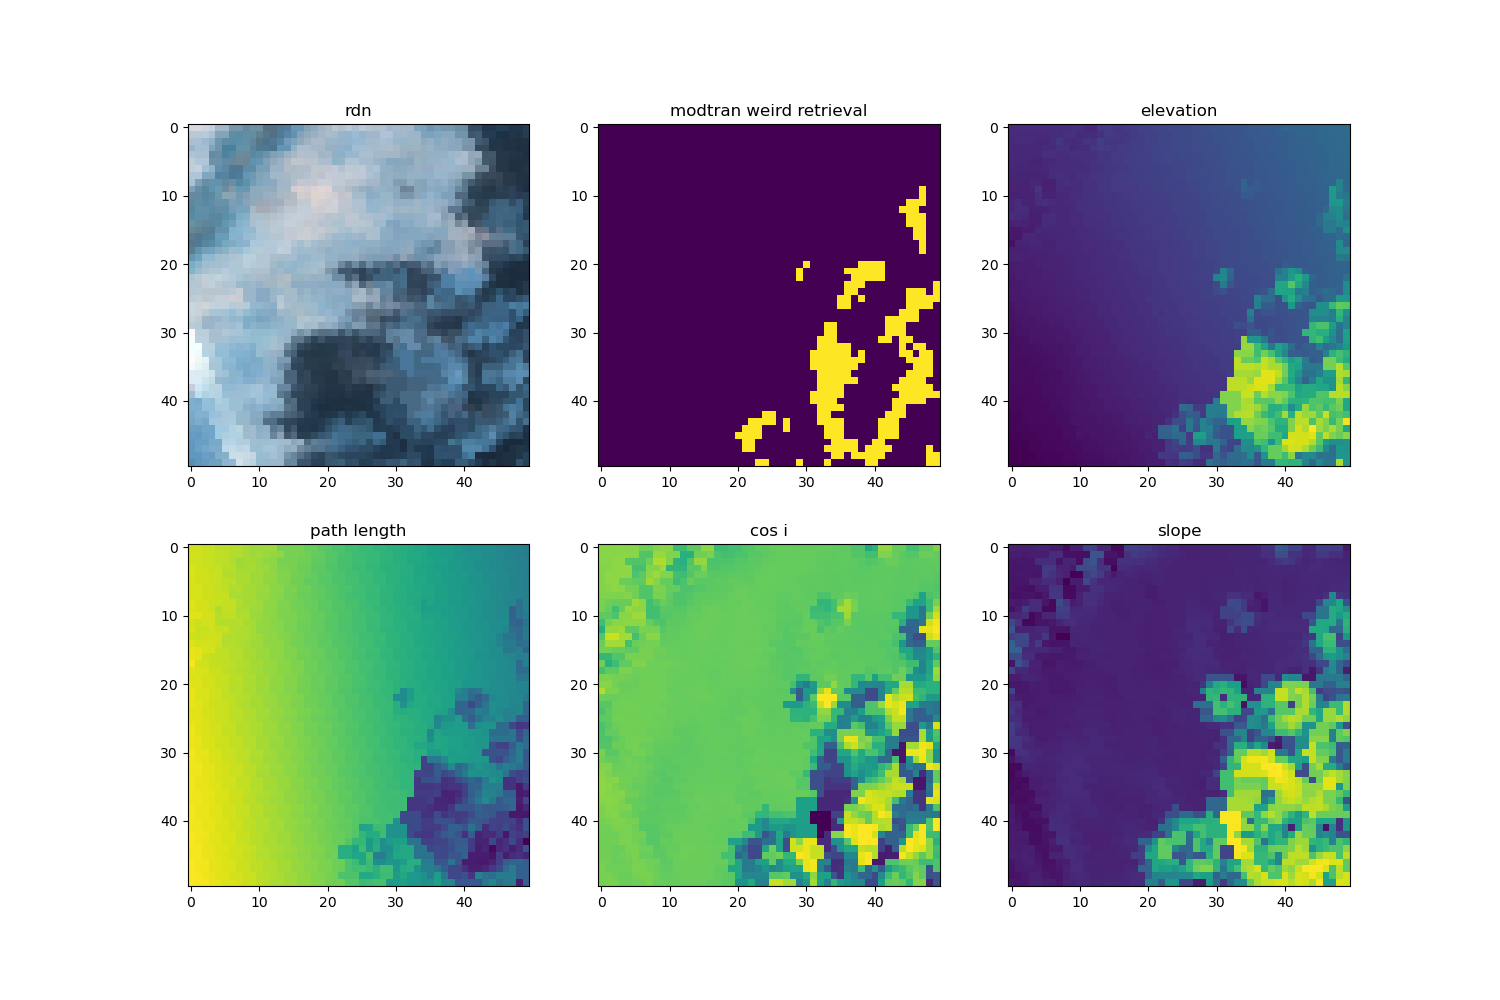

In [19]:
# thinking more about where retrievals are weird

size = 50
row1 = 0; col1 = 0

working_dir = os.path.join(home, 'NIS01_20180612_155442_modtran_20250922')
fp = glob(os.path.join(working_dir, 'output', f'{flight_id}_rfl.hdr'))[0]
weird = envi.open(fp).open_memmap()
weird = (weird > 1).any(axis=2, keepdims=True)
weird = weird.squeeze(-1)

fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(15,10))

fp = glob(os.path.join(raw_dir, f'{flight_id}_rdn.hdr'))[0]
rgb = envi.open(fp).open_memmap()[:,:,np.array([60,40,30])].copy()
axs[0,0].imshow(rgb / np.nanmax(rgb, axis=(0, 1)))
axs[0,0].set_title('rdn')

axs[0,1].imshow(weird)
axs[0,1].set_title('modtran weird retrieval')

fp = glob(os.path.join(raw_dir, f'{flight_id}_loc.hdr'))[0]
loc = envi.open(fp).open_memmap()[...,2]
axs[0,2].imshow(loc)
axs[0,2].set_title('elevation')

fp = glob(os.path.join(raw_dir, f'{flight_id}_obs.hdr'))[0]
obs = envi.open(fp).open_memmap()
axs[1,0].imshow(obs[...,0])
axs[1,0].set_title('path length')
axs[1,1].imshow(obs[...,8])
axs[1,1].set_title('cos i')
axs[1,2].imshow(obs[...,6])
axs[1,2].set_title('slope')

plt.show()
# viz_rfl_subset(flight=flight_id, working_dir=working_dir, row1=row1, col1=col1, size=size, n_sample=20, wl=wl)


(2241, 426) (50, 50)


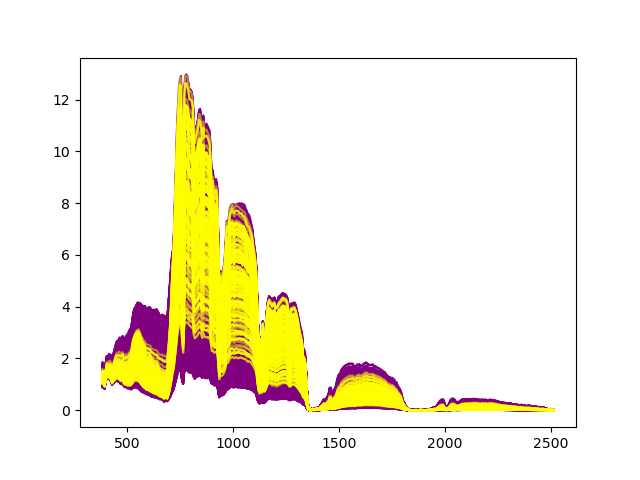

In [26]:
# rdn values for weird, not weird retrievals?

fp = glob(os.path.join(raw_dir, f'{flight_id}_rdn.hdr'))[0]
rgb = envi.open(fp).open_memmap()

not_weird_px = rgb[weird==False]
weird_px = rgb[weird==True]
print(not_weird.shape, weird.shape)

fig = plt.figure()
plt.plot(wl, not_weird_px.T, color='purple', alpha=1)
plt.plot(wl, weird_px.T, color='yellow', alpha=0.5)
plt.show()